### 분석목표
 데이터를 정제한 뒤 반납 지연(late_return)과 관련된 운영 패턴 찾기

In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

def iqr_bounds(series):
    clean = series.dropna()
    q1, q3 = clean.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return lower, upper, int(((clean < lower) | (clean > upper)).sum())

raw = pd.read_csv('A_공유자전거_대여운영_dirty.csv')


### 문제 1. 데이터 구조와 품질 문제 확인

In [122]:
raw.head() # 데이터의 첫5행 확인

,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return
0,R0001,공원,일일권,비,31.5,77.0,5.6,4.11,NaN,28.0,0
1,R0002,도심,월회원,흐림,23.3,74.6,4.6,1.35,11.0,33.0,0
2,R0003,공원,일일권,맑음,22.5,56.3,1.0,1.49,11.6,31.0,0
3,R0004,공원,연회원,흐림,28.6,77.3,2.0,6.73,27.5,21.0,0
4,R0005,공원,월회원,맑음,13.0,46.3,0.8,3.09,17.5,42.0,0


In [123]:
raw.shape # (행 개수, 열 개수) --> 튜플로 반환

(652, 11)

In [124]:
raw.info() # 652 보다 낮게 나오는 컬럼이 결측차가 있는 컬럼

<class 'pandas.DataFrame'>
RangeIndex: 652 entries, 0 to 651
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rental_id          652 non-null    str    
 1   station_zone       652 non-null    str    
 2   member_type        629 non-null    str    
 3   weather            635 non-null    str    
 4   temperature_c      652 non-null    float64
 5   humidity_pct       627 non-null    float64
 6   wind_speed_mps     652 non-null    float64
 7   distance_km        652 non-null    float64
 8   ride_duration_min  631 non-null    float64
 9   bike_age_months    638 non-null    float64
 10  late_return        652 non-null    int64  
dtypes: float64(6), int64(1), str(4)
memory usage: 56.2 KB


In [125]:
# describe()만 사용하면 수치형 컬럼의 평균/표준편차/최솟값/최댓값등 만 보여준다.
# include="all"을 추가하면 문자열(범주형)컬럼의 통계(고유값개수, 최빈값 등) 까지 같이 보여준다.
raw.describe(include="all")

,rental_id,station_zone,member_type,weather,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,late_return
count,652,652,629,635,652.000000,627.000000,652.000000,652.000000,631.000000,638.000000,652.000000
unique,644,4,3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,R0019,주거,월회원,맑음,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,2,192,245,375,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,22.854755,62.670175,3.218558,4.318466,22.682092,22.354232,0.050613
std,NaN,NaN,NaN,NaN,6.487134,15.228703,1.392390,5.384499,24.133076,10.928047,0.219375
min,NaN,NaN,NaN,NaN,-19.100000,28.000000,0.200000,0.680000,4.000000,1.000000,0.000000
25%,NaN,NaN,NaN,NaN,19.000000,51.750000,2.200000,2.180000,13.500000,14.000000,0.000000
50%,NaN,NaN,NaN,NaN,22.600000,61.500000,3.200000,3.280000,18.600000,22.000000,0.000000
75%,NaN,NaN,NaN,NaN,27.225000,72.100000,4.200000,4.910000,24.900000,29.000000,0.000000


In [126]:
# .isna(): 각 칸이 결측이면 True 아니면 False인 표를 제작
# .sum(): True는 1 처럼 계산되어 컬럼별 결측치 개수가 나옴
# .mean(): True / False의 평균 = 결측치 비율 나옴

audit = pd.DataFrame({
    "missing_count": raw.isna().sum(),
    "missing_ratio": raw.isna().mean()
})
audit

,missing_count,missing_ratio
rental_id,0,0.000000
station_zone,0,0.000000
member_type,23,0.035276
weather,17,0.026074
temperature_c,0,0.000000
humidity_pct,25,0.038344
wind_speed_mps,0,0.000000
distance_km,0,0.000000
ride_duration_min,21,0.032209
bike_age_months,14,0.021472


In [127]:
# duplicated(): 각 행이 바로 이전에 나온 행과 모든 컬럼 값이 
#               완전히 같으면 True를 반환 .sum()으로 개수를 센다 (6개)
raw.duplicated().sum()

np.int64(6)

In [128]:
# rental_id: 분석 피처가 아니라 대여 건을 구별하는 식별자
print("rental_id 중복:",raw["rental_id"].duplicated().sum())

rental_id 중복: 8


### 문제 2. 중복과 결측치 처리

In [129]:
# drop_duplicates(): 완전히 똑같은 행 중 첫 번쨈나 남기고 나머지를 삭제
# .copy(): pandas가 원본의 일부를 보고 있는 상태(view)로 취급해서 나중에 dedup을 
#          수정할때 경고가 뜨거나 예상 못한 동작이 생길 수 있다.
dedup = raw.drop_duplicates().copy()
dedup.shape[0]

646

In [130]:
# select_dtypes(include="number"): 숫자로된 컬럼만 골라낸다
# .difference(["late_return"]): late_return만 빼기, late_return 숫자지만 사실 0/1 범주형 타깃이라 평균 계산에서 제외해야 함

# rental_id는 같은데 값이 다른 행은 그룹화해서 통합 (late_return은 평균 대신 첫 값 사용)
numeric_cols = dedup.select_dtypes(include="number").columns.difference(["late_return"])

In [131]:
aggregate = {col: "first" for col in dedup.columns if col not in {"rental_id", *numeric_cols}}

In [132]:
aggregate = {}
for col in dedup.columns:
    if col not in {"rental_id", *numeric_cols}:   # rental_id도 아니고, 평균 낼 숫자 컬럼도 아니면
        aggregate[col] = "first"                   # "첫 값을 쓰겠다"고 표시

In [133]:
aggregate.update({col: "mean" for col in numeric_cols})

In [134]:
df = dedup.groupby("rental_id", as_index=False, sort=False).agg(aggregate)
df

,rental_id,station_zone,member_type,weather,late_return,bike_age_months,distance_km,humidity_pct,ride_duration_min,temperature_c,wind_speed_mps
0,R0001,공원,일일권,비,0,28.0,4.11,77.0,NaN,31.5,5.6
1,R0002,도심,월회원,흐림,0,33.0,1.35,74.6,11.0,23.3,4.6
2,R0003,공원,일일권,맑음,0,31.0,1.49,56.3,11.6,22.5,1.0
3,R0004,공원,연회원,흐림,0,21.0,6.73,77.3,27.5,28.6,2.0
4,R0005,공원,월회원,맑음,0,42.0,3.09,46.3,17.5,13.0,0.8
...,...,...,...,...,...,...,...,...,...,...,...
639,R0640,주거,월회원,비,0,1.0,1.52,77.7,NaN,30.6,4.8
640,R0641,대학가,일일권,비,0,23.0,6.19,69.4,35.4,25.8,4.6
641,R0642,대학가,연회원,흐림,0,NaN,1.53,80.8,8.6,22.4,5.5
642,R0643,주거,월회원,맑음,0,27.0,3.08,64.0,17.9,31.6,3.4


In [135]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 644 entries, 0 to 643
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   rental_id          644 non-null    str    
 1   station_zone       644 non-null    str    
 2   member_type        622 non-null    str    
 3   weather            627 non-null    str    
 4   late_return        644 non-null    int64  
 5   bike_age_months    630 non-null    float64
 6   distance_km        644 non-null    float64
 7   humidity_pct       619 non-null    float64
 8   ride_duration_min  623 non-null    float64
 9   temperature_c      644 non-null    float64
 10  wind_speed_mps     644 non-null    float64
dtypes: float64(6), int64(1), str(4)
memory usage: 55.5 KB


In [136]:
for col in ["member_type", "weather"]:
    df[col] = df[col].fillna("미상")
for col in ["humidity_pct", "ride_duration_min", "bike_age_months"]:
    df[col] = df[col].fillna(df[col].median())

df.shape

(644, 11)

In [137]:
df.isnull().sum()

rental_id            0
station_zone         0
member_type          0
weather              0
late_return          0
bike_age_months      0
distance_km          0
humidity_pct         0
ride_duration_min    0
temperature_c        0
wind_speed_mps       0
dtype: int64

### 문제 3. 이상치 탐지와 처리 전략

<Axes: >

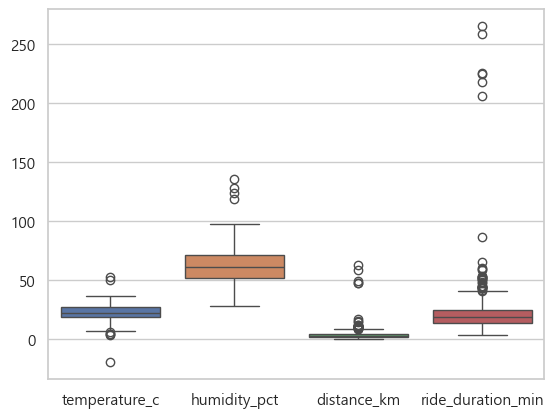

In [138]:
outlier_cols = ["temperature_c", "humidity_pct", "distance_km", "ride_duration_min"]

sns.boxplot(data=df[outlier_cols])

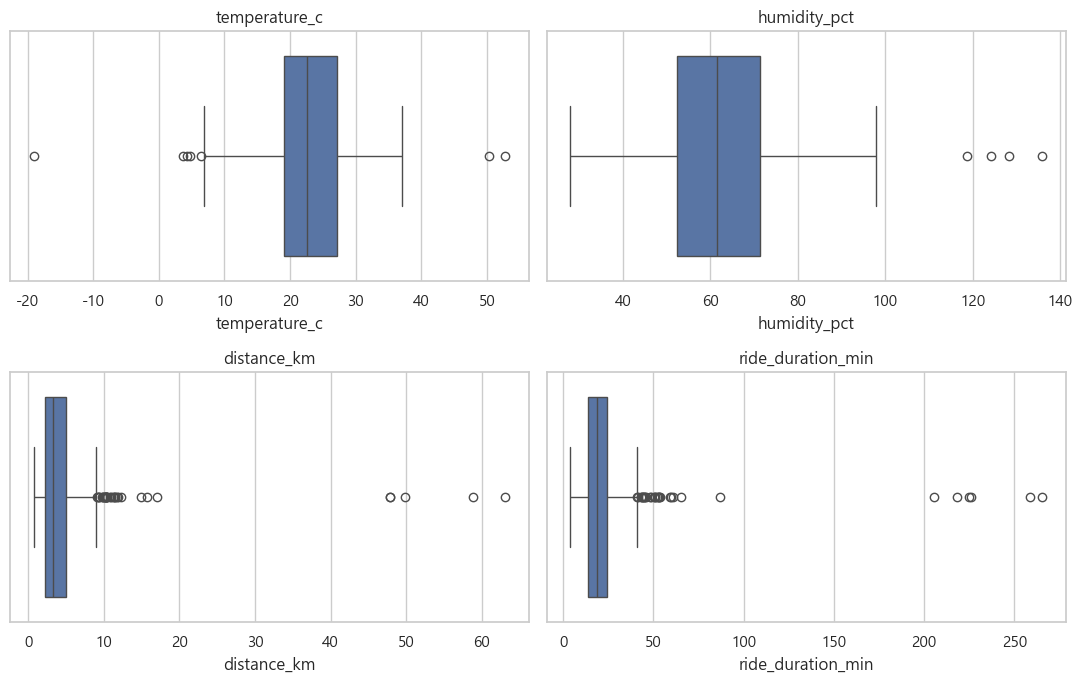

In [139]:
# 컬럼마다 단위(스케일)가 달라서 한 그래프에 모아 그리면 서로 비교가 잘 안 됨
# -> 컬럼별로 따로 그려서 각자의 분포를 자세히 확인
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for col, ax in zip(outlier_cols, axes.flat):
    sns.boxplot(x=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()


# - `plt.subplots(2, 2, figsize=(11, 7))` : 2행×2열, 총 4칸짜리 그래프 틀을 만듦. `fig`는 전체 그림, `axes`는 4개 칸(2×2 배열) 각각을 가리킵니다.
# - `axes.flat` : 2×2 배열을 1줄(4칸)로 펴서, `for`문으로 하나씩 순서대로 꺼내 쓸 수 있게 함
# - `zip(outlier_cols, axes.flat)` : 컬럼 이름 4개와 그래프 칸 4개를 짝지어서 동시에 반복
# - `ax.set_title(col)` : 각 칸에 컬럼 이름을 제목으로 붙임
# - `plt.tight_layout()` : 서브플롯끼리 겹치지 않게 여백을 자동으로 조절

In [140]:
bounds = {}
for col in outlier_cols:
    q1 = df[col].quantile(.25)
    q3 = df[col].quantile(.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = ((df[col] < lower) | (df[col] > upper)).sum()
    bounds[col] = {"lower": lower, "upper": upper, "outlier_count": count}

pd.DataFrame(bounds).T

,lower,upper,outlier_count
temperature_c,6.700,39.500,7.0
humidity_pct,23.800,99.800,4.0
distance_km,-1.915,9.005,33.0
ride_duration_min,-2.750,40.850,31.0


In [141]:
# 습도는 0~100% 범위를 벗어나면 명백한 오류 -> capping
df["humidity_range_error"] = (~df["humidity_pct"].between(0, 100)).astype("int8")
df["humidity_pct"] = df["humidity_pct"].clip(0, 100)


# - `.between(0, 100)` : 0 이상 100 이하면 True
# - `~` : 앞의 True/False를 뒤집는 기호(부정). 즉 "0~100 범위를 **벗어나면**" True가 됨
# - `.astype("int8")` : True/False를 1/0 숫자로 바꾸고, 저장 공간을 아끼기 위해 작은 정수 타입(int8)으로 지정
# - `.clip(0, 100)` : 0보다 작은 값은 0으로, 100보다 큰 값은 100으로 눌러줌 (지난번에 설명한 capping)


In [142]:
# 나머지는 실제로 있을 수 있는 값이므로 원본은 유지하고 이상치 여부만 플래그로 남김
for col in ["temperature_c", "distance_km", "ride_duration_min"]:
    lower, upper, _ = iqr_bounds(df[col])
    df[f"{col}_outlier"] = ((df[col] < lower) | (df[col] > upper)).astype("int8")

In [143]:
df[["humidity_range_error", "temperature_c_outlier", "distance_km_outlier", "ride_duration_min_outlier"]].sum()

humidity_range_error          4
temperature_c_outlier         7
distance_km_outlier          33
ride_duration_min_outlier    31
dtype: int64

### 문제 4. 파생변수, 인코딩, 스케일링

In [144]:
df["avg_speed_kmh"] = df["distance_km"].div(df["ride_duration_min"].div(60))
df["avg_speed_kmh"].describe()

count    644.000000
mean      12.866638
std       22.046862
min        0.420029
25%        9.267358
50%       11.093866
75%       12.867059
max      360.800000
Name: avg_speed_kmh, dtype: float64

In [145]:
# 0으로 나누거나 inf가 생기지 않았는지 확인
np.isfinite(df["avg_speed_kmh"]).all()

np.True_

In [146]:
df["speed_outlier"] = df["avg_speed_kmh"].gt(60).astype("int")
df["speed_outlier"].sum()

np.int64(5)

In [147]:
# eq() : ==
# gt() : "greater than"의 약자로, > 연산자와 완전히 같은 뜻
df["bad_weather"] = df["weather"].eq("비").astype("int8")
df["old_bike"] = df["bike_age_months"].gt(df["bike_age_months"].median()).astype("int8")

In [148]:
# 원핫 인코딩
model_df = pd.get_dummies(df, columns=["station_zone", "member_type", "weather"], dtype="int8")

In [149]:
scale_cols = ["temperature_c", "humidity_pct", "wind_speed_mps", "distance_km",
              "ride_duration_min", "bike_age_months", "avg_speed_kmh"]
model_df[scale_cols] = StandardScaler().fit_transform(model_df[scale_cols])
model_df[scale_cols].describe().loc[["mean", "std"]]

,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months,avg_speed_kmh
mean,-1.875656e-16,-2.813484e-16,-3.034150e-16,-9.102450e-17,5.516636e-17,6.068300e-17,-1.434325e-16
std,1.000777e+00,1.000777e+00,1.000777e+00,1.000777e+00,1.000777e+00,1.000777e+00,1.000777e+00


In [150]:
model_df.to_csv("A_공유자전거_cleaned.csv", index=False)
print("저장 완료:", model_df.shape)

저장 완료: (644, 28)


### 문제 5. 단변량 분포와 표본 불균형 확인

Text(0.5, 1.0, '이용 시간 분포')

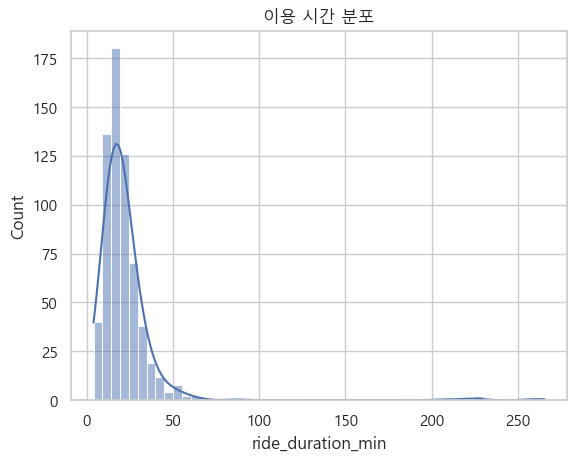

In [151]:
sns.histplot(data=df, x="ride_duration_min", kde=True)
plt.title("이용 시간 분포")

Text(0.5, 1.0, '권역별 대여 건수')

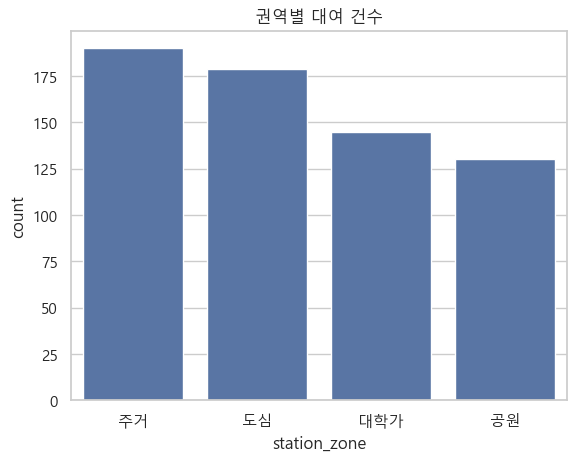

In [152]:
sns.countplot(data=df, x="station_zone", order=df["station_zone"].value_counts().index)
plt.title("권역별 대여 건수")

In [153]:
late_summary = df["late_return"].value_counts().to_frame("count")
late_summary["ratio"] = df["late_return"].value_counts(normalize=True)
late_summary

,count,ratio
late_return,,
0,613,0.951863
1,31,0.048137


### 문제 6. 수치형 변수 관계 분석

In [154]:
corr_cols = ["temperature_c", "humidity_pct", "wind_speed_mps", "distance_km", "ride_duration_min", "bike_age_months"]
corr = df[corr_cols].corr()
corr

,temperature_c,humidity_pct,wind_speed_mps,distance_km,ride_duration_min,bike_age_months
temperature_c,1.000000,-0.175131,-0.149652,0.009624,-0.012049,-0.033978
humidity_pct,-0.175131,1.000000,0.244864,-0.000419,0.120845,-0.002881
wind_speed_mps,-0.149652,0.244864,1.000000,-0.054912,0.013700,-0.048922
distance_km,0.009624,-0.000419,-0.054912,1.000000,0.164321,-0.031146
ride_duration_min,-0.012049,0.120845,0.013700,0.164321,1.000000,0.002360
bike_age_months,-0.033978,-0.002881,-0.048922,-0.031146,0.002360,1.000000


Text(0.5, 1.0, '수치형 변수 상관관계')

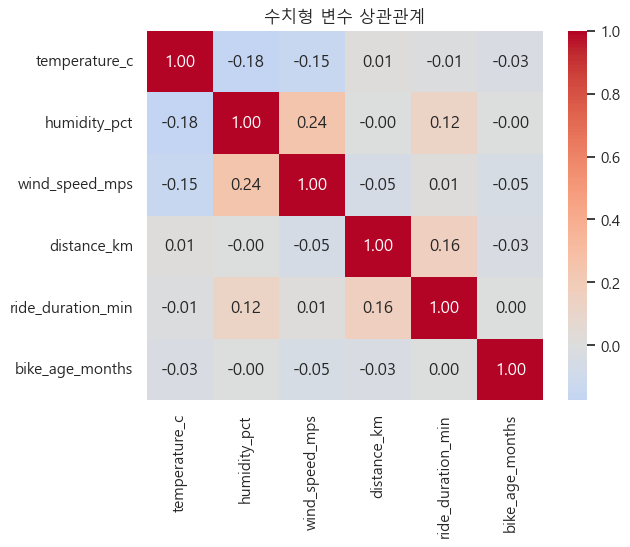

In [155]:
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("수치형 변수 상관관계")

In [156]:
pairs = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool)).stack()
top_pair = pairs.abs().idxmax()
top_pair, corr.loc[top_pair]

(('humidity_pct', 'wind_speed_mps'), np.float64(0.24486416372756445))

Text(0.5, 1.0, '이동 거리 vs 이용 시간')

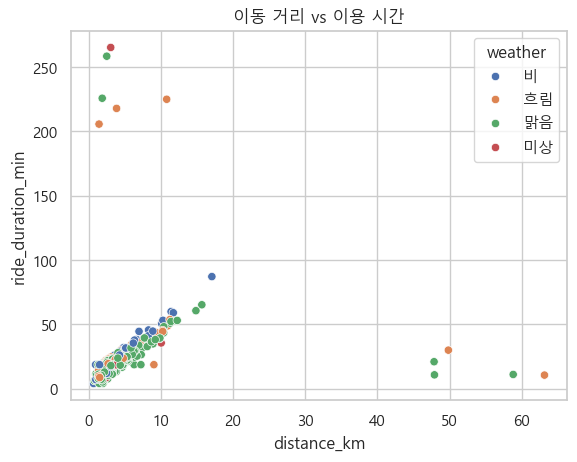

In [157]:
sns.scatterplot(data=df, x="distance_km", y="ride_duration_min", hue="weather")
plt.title("이동 거리 vs 이용 시간")

### 문제 7. 그룹 비교 분석

Text(0.5, 1.0, '이용권 유형별 이용 시간')

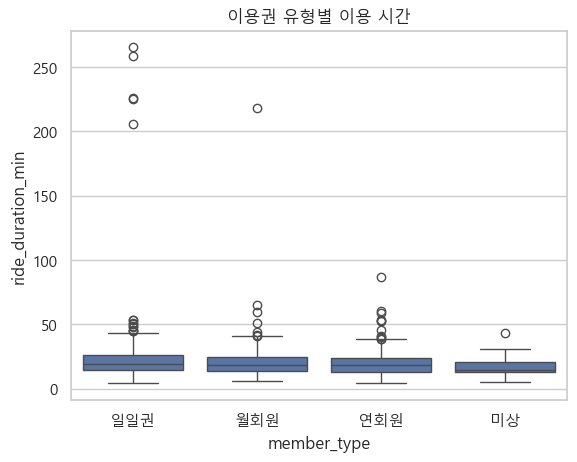

In [158]:
sns.boxplot(data=df, x="member_type", y="ride_duration_min")
plt.title("이용권 유형별 이용 시간")

In [159]:
df.groupby("weather")[["distance_km", "ride_duration_min"]].mean()

,distance_km,ride_duration_min
weather,,
맑음,4.234367,20.762803
미상,3.216471,32.000000
비,4.145376,23.815054
흐림,4.436810,23.893865


In [160]:
zone_late = df.groupby("station_zone")["late_return"].agg(count="size", late_count="sum", late_ratio="mean")
zone_late

,count,late_count,late_ratio
station_zone,,,
공원,130,4,0.030769
대학가,145,5,0.034483
도심,179,10,0.055866
주거,190,12,0.063158


### 8번 운영 인사이트 작성

In [161]:
weather_stats = df.groupby("weather").agg(
    n=("rental_id", "size"), mean_distance=("distance_km", "mean"), mean_duration=("ride_duration_min", "mean")
)
weather_stats

,n,mean_distance,mean_duration
weather,,,
맑음,371,4.234367,20.762803
미상,17,3.216471,32.000000
비,93,4.145376,23.815054
흐림,163,4.436810,23.893865


In [162]:
highest_zone = zone_late["late_ratio"].idxmax()
longest_weather = weather_stats.drop(index="미상", errors="ignore")["mean_duration"].idxmax()
highest_zone, longest_weather

('주거', '흐림')

In [163]:
print(f"1) {highest_zone}의 지연율은 {zone_late.loc[highest_zone, 'late_ratio']:.1%}"
      f"(n={zone_late.loc[highest_zone, 'count']:.0f})로 가장 높지만 인과로 단정할 수 없다.")
print(f"2) {longest_weather}의 평균 이용 시간은 {weather_stats.loc[longest_weather, 'mean_duration']:.1f}분이다.")
print(f"3) 습도 범위 오류 {df['humidity_range_error'].sum()}건을 보정했으므로 원본 유지 결과와도 비교해야 한다.")

1) 주거의 지연율은 6.3%(n=190)로 가장 높지만 인과로 단정할 수 없다.
2) 흐림의 평균 이용 시간은 23.9분이다.
3) 습도 범위 오류 4건을 보정했으므로 원본 유지 결과와도 비교해야 한다.
